# Exploratory Data Analysis (EDA) on the Ames Iowa Housing Prices dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Goal of the project is to predict housing prices. 
Let's load the data and get a feeling of the dataset. First we need to check if the data needs to be cleaned up.

In [2]:
housing_data = pd.read_csv('data/train.csv')

# Display basic information about the dataset
print(housing_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [3]:
# Separate the columns into numerical and categorical
numerical_cols = housing_data.select_dtypes(include=['int64', 'float64']).columns
cathegorical_cols = housing_data.select_dtypes(include=['str']).columns

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {cathegorical_cols}")

Numerical columns: Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')
Categorical columns: Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1'

## Data Cleanup and pre-processing

In [4]:
# Check which columns have missing values
missing_values = housing_data.isnull().sum()
missing_values.sort_values(ascending=False, inplace=True)

# Display columns with missing values
print("Columns with missing values:")

print(f"{'Name':<15} {'Type':<10} \t: {'Count'} {'Percentage':<10}")
for col, count in missing_values.items():
    if count > 0:
        perc = count / len(housing_data) * 100
        type = 'Numerical' if col in numerical_cols else 'Categorical'
        print(f"{col:<15} {type:<10} \t: {count}\t({perc:.2f}%)")

Columns with missing values:
Name            Type       	: Count Percentage
PoolQC          Categorical 	: 1453	(99.52%)
MiscFeature     Categorical 	: 1406	(96.30%)
Alley           Categorical 	: 1369	(93.77%)
Fence           Categorical 	: 1179	(80.75%)
MasVnrType      Categorical 	: 872	(59.73%)
FireplaceQu     Categorical 	: 690	(47.26%)
LotFrontage     Numerical  	: 259	(17.74%)
GarageQual      Categorical 	: 81	(5.55%)
GarageFinish    Categorical 	: 81	(5.55%)
GarageType      Categorical 	: 81	(5.55%)
GarageYrBlt     Numerical  	: 81	(5.55%)
GarageCond      Categorical 	: 81	(5.55%)
BsmtFinType2    Categorical 	: 38	(2.60%)
BsmtExposure    Categorical 	: 38	(2.60%)
BsmtCond        Categorical 	: 37	(2.53%)
BsmtQual        Categorical 	: 37	(2.53%)
BsmtFinType1    Categorical 	: 37	(2.53%)
MasVnrArea      Numerical  	: 8	(0.55%)
Electrical      Categorical 	: 1	(0.07%)


#### Notes:
- Many of these features have a NAN to represent no data or the item not being present (e.g. Pool, Fence, Alley)
- MiscFeature could be transformed in specific features with 1-Hot encoding, but for this exercise we can drop it.
- MasVnrArea and LotFrontage can be imputed.
- GarageYrBlt is NAN when the garage is not present. Perhaps we can introduce a 1-Hot encoder to indicate if the garage is present. 

In [5]:
# Setting the missing garage year built to zero
housing_data['GarageYrBlt'] = housing_data['GarageYrBlt'].fillna(0)

# Imputation of the missing numerical values with the median
for col in numerical_cols:
    if housing_data[col].isnull().sum() > 0:
        median_value = housing_data[col].median()
        housing_data[col] = housing_data[col].fillna(median_value)
        
# Set the NA values of the cathegorical values to 'None' to indicate it is not present.
for col in cathegorical_cols:
    if housing_data[col].isnull().sum() > 0:
        housing_data[col] = housing_data[col].fillna('None')

## Analysis of Numerical Data for Feature selection

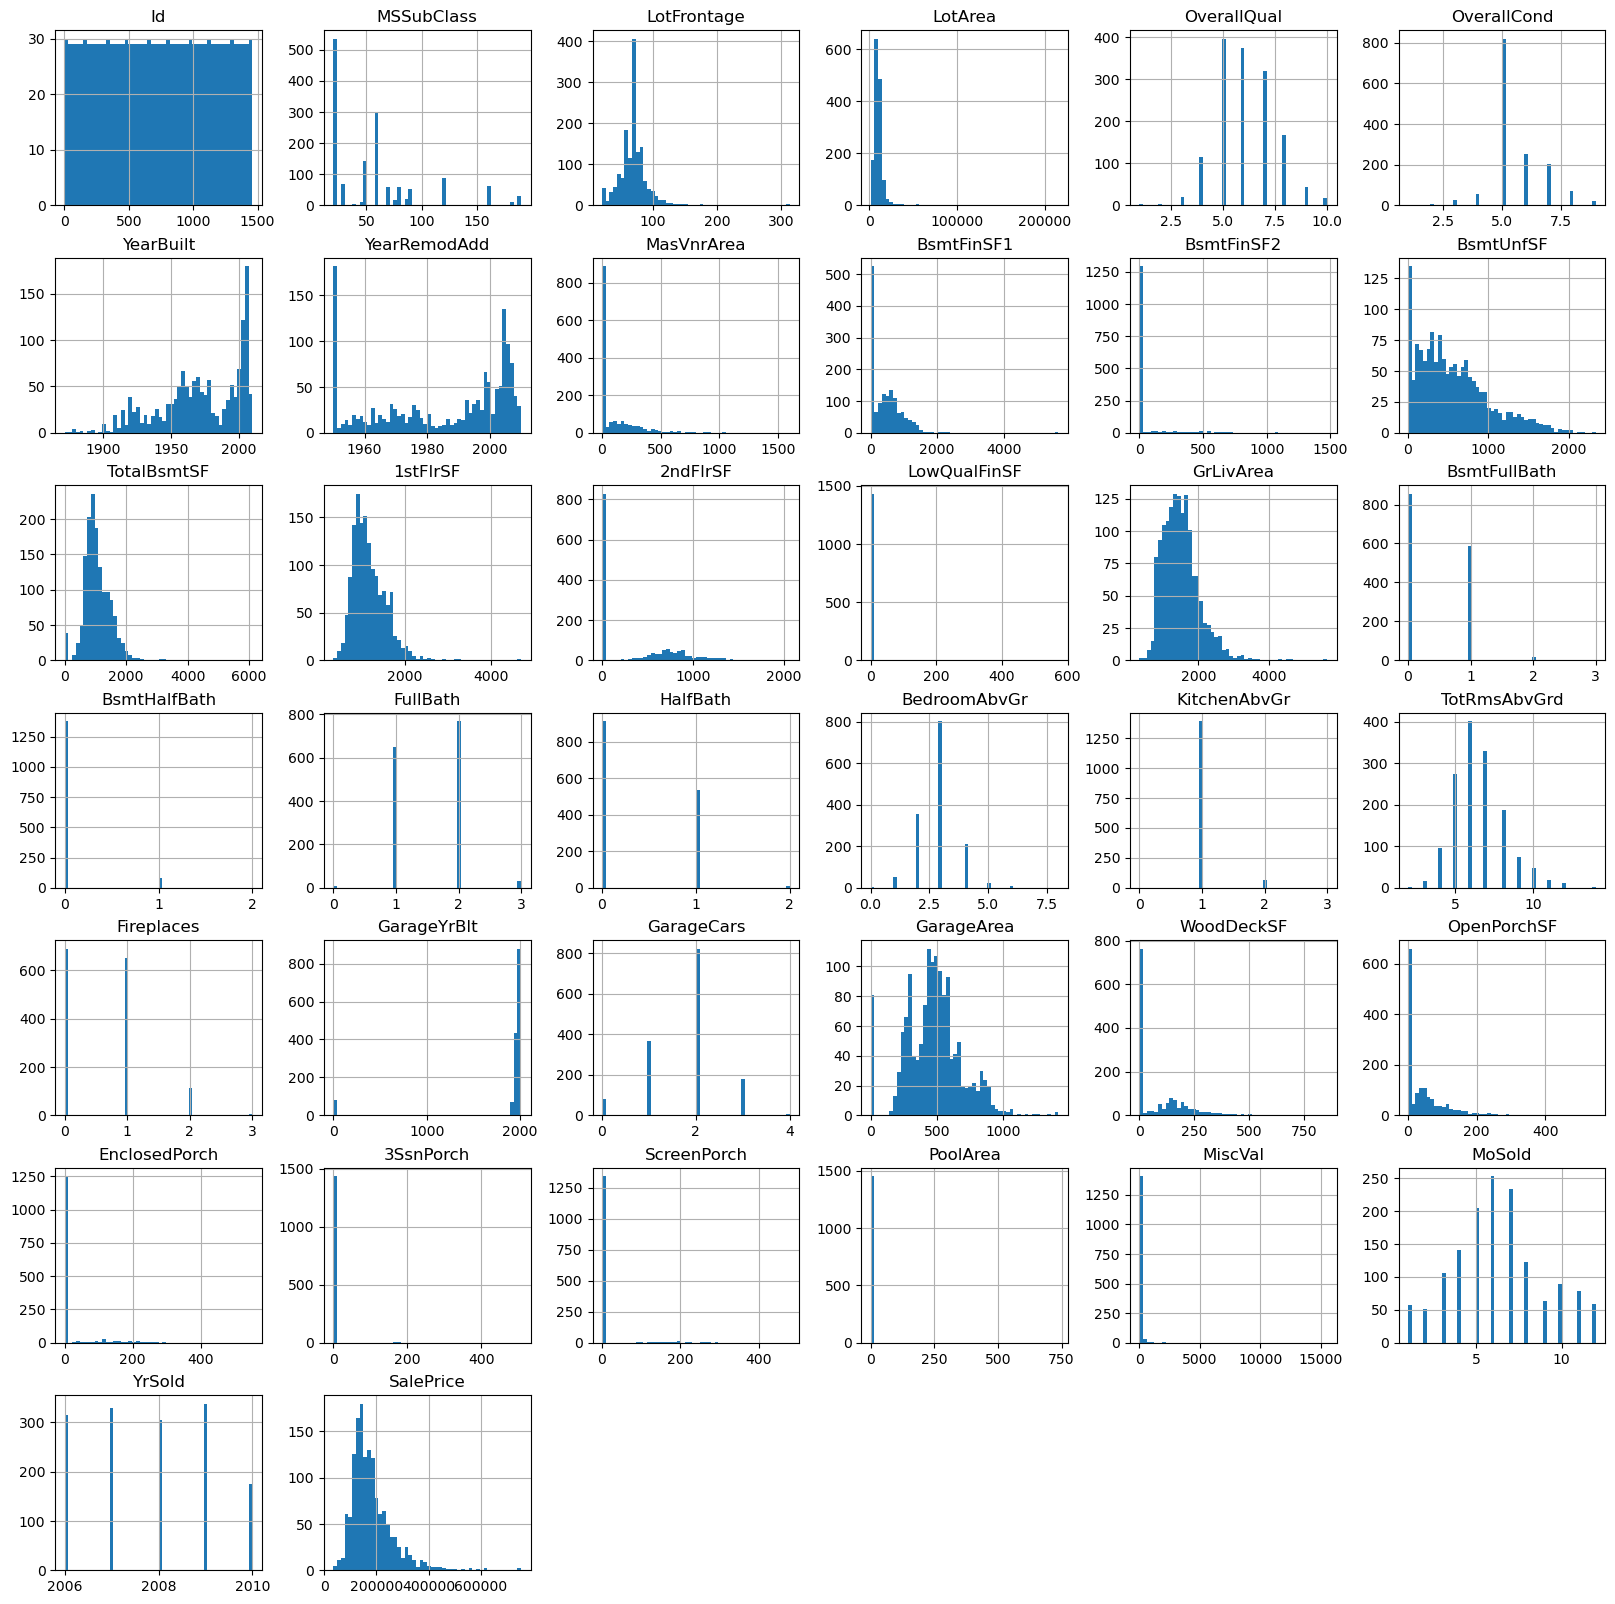

In [6]:
_ = housing_data[numerical_cols].hist(figsize=(20, 20), bins=50)

# Some of these features will need to be normalized, if they get selected.

<Axes: >

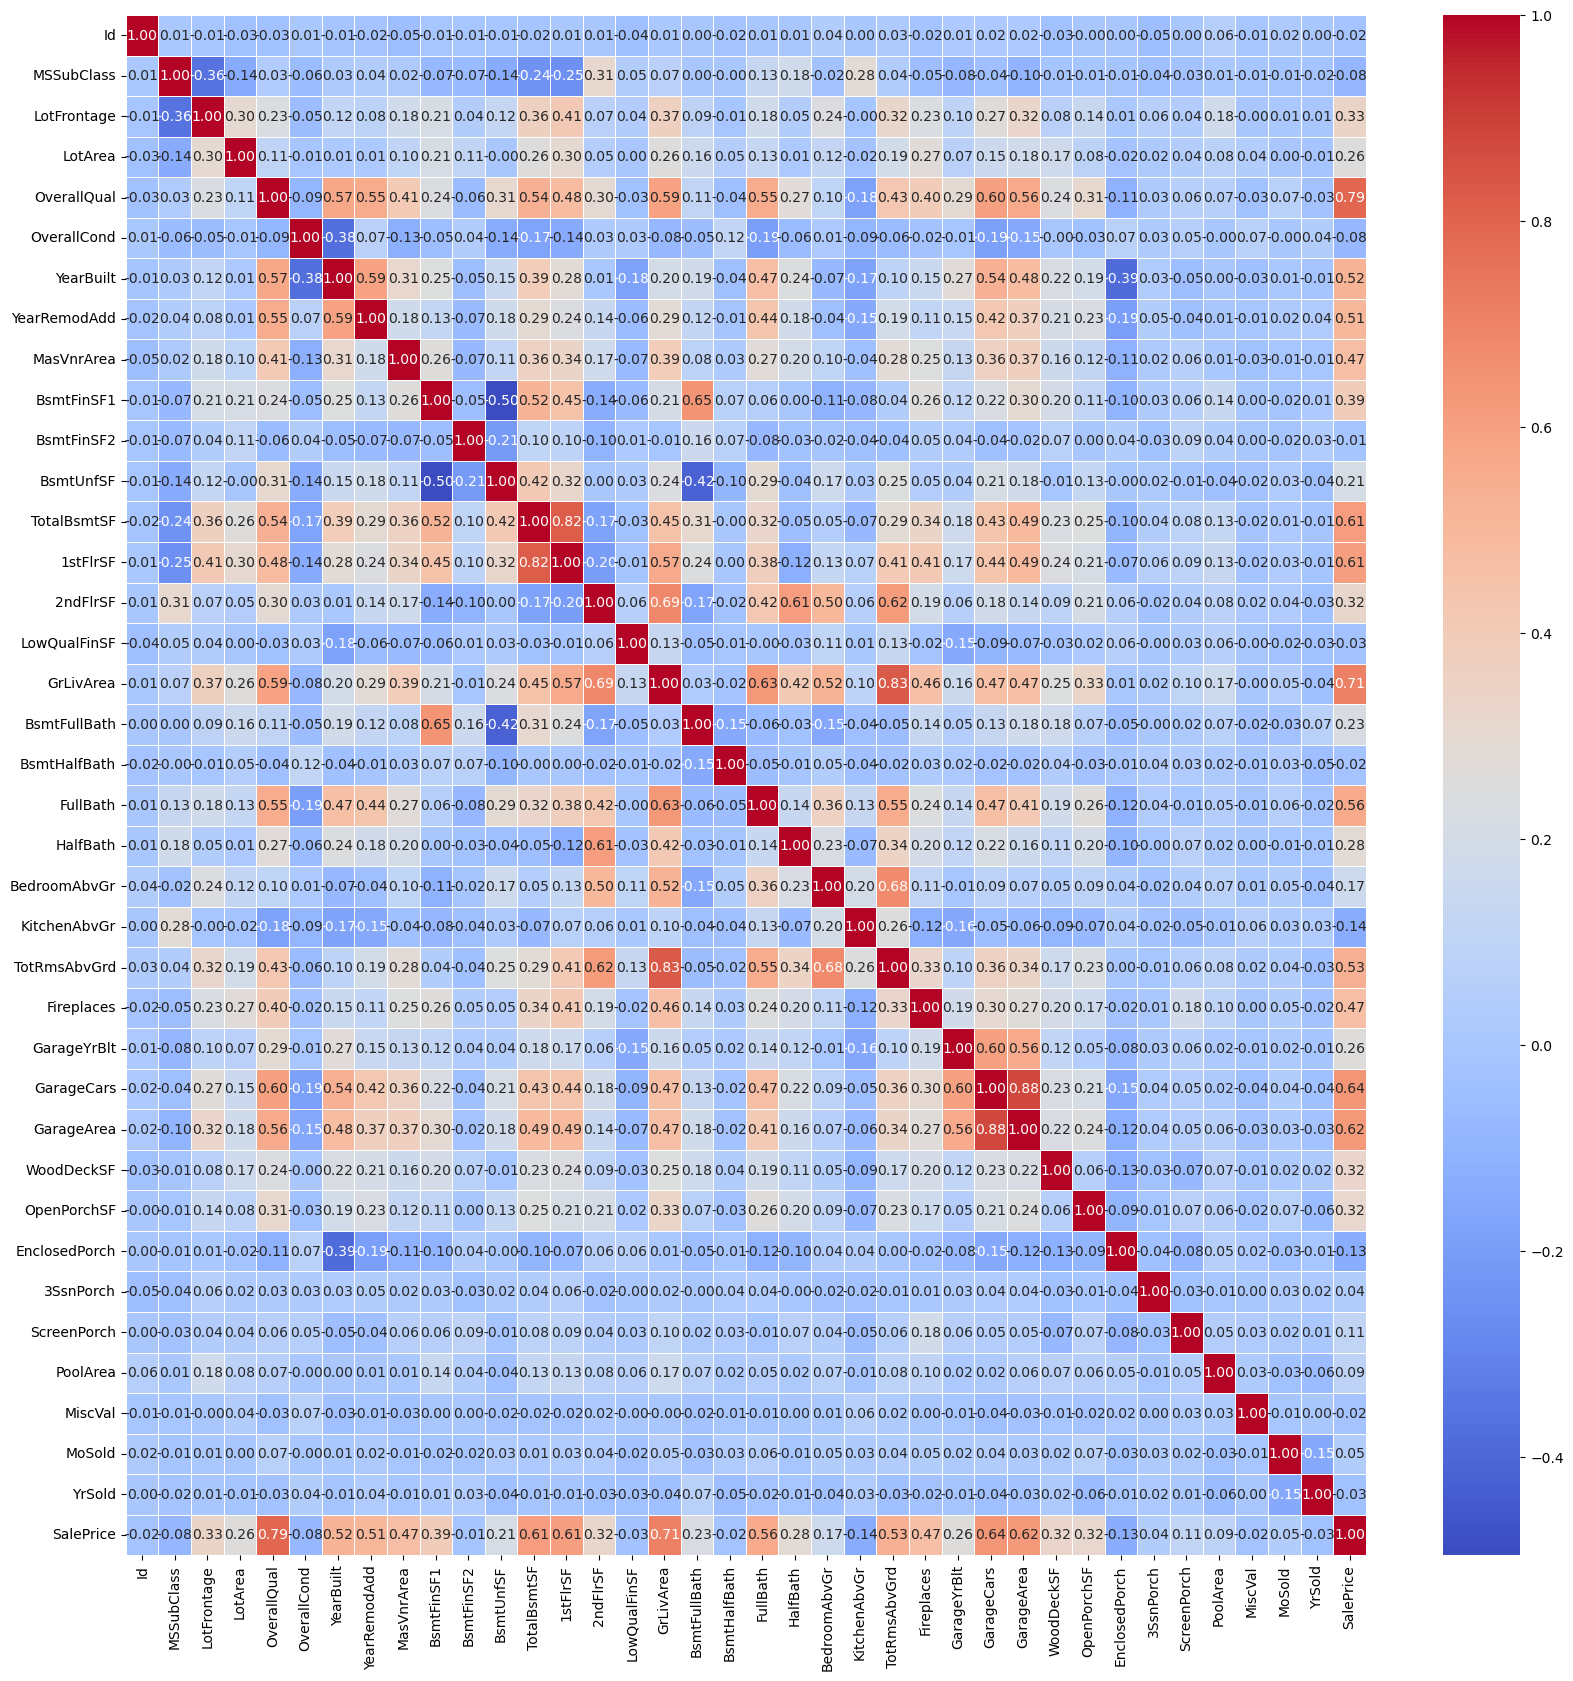

In [7]:
# Corr of all variables
plt.figure(figsize=(20, 20))
sns.heatmap(housing_data[numerical_cols].corr(), 
            annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

<Axes: >

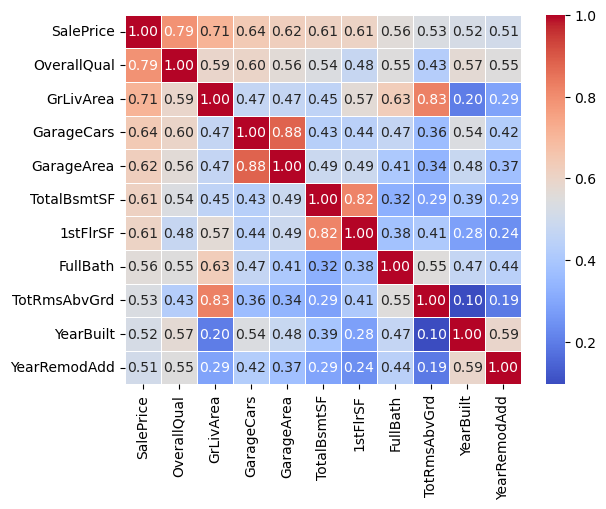

In [8]:
# Do a correlation matrix of the strongest variables correlated with SalePrice
corr_target = housing_data[numerical_cols].corr()['SalePrice'].sort_values(ascending=False, key=abs)

# Take the 30% top of the list
top_20_percent = int(len(corr_target) * 0.3)
top_vars = corr_target.head(top_20_percent)

corr = housing_data[top_vars.index].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

## Analysis of Cathegorical Data

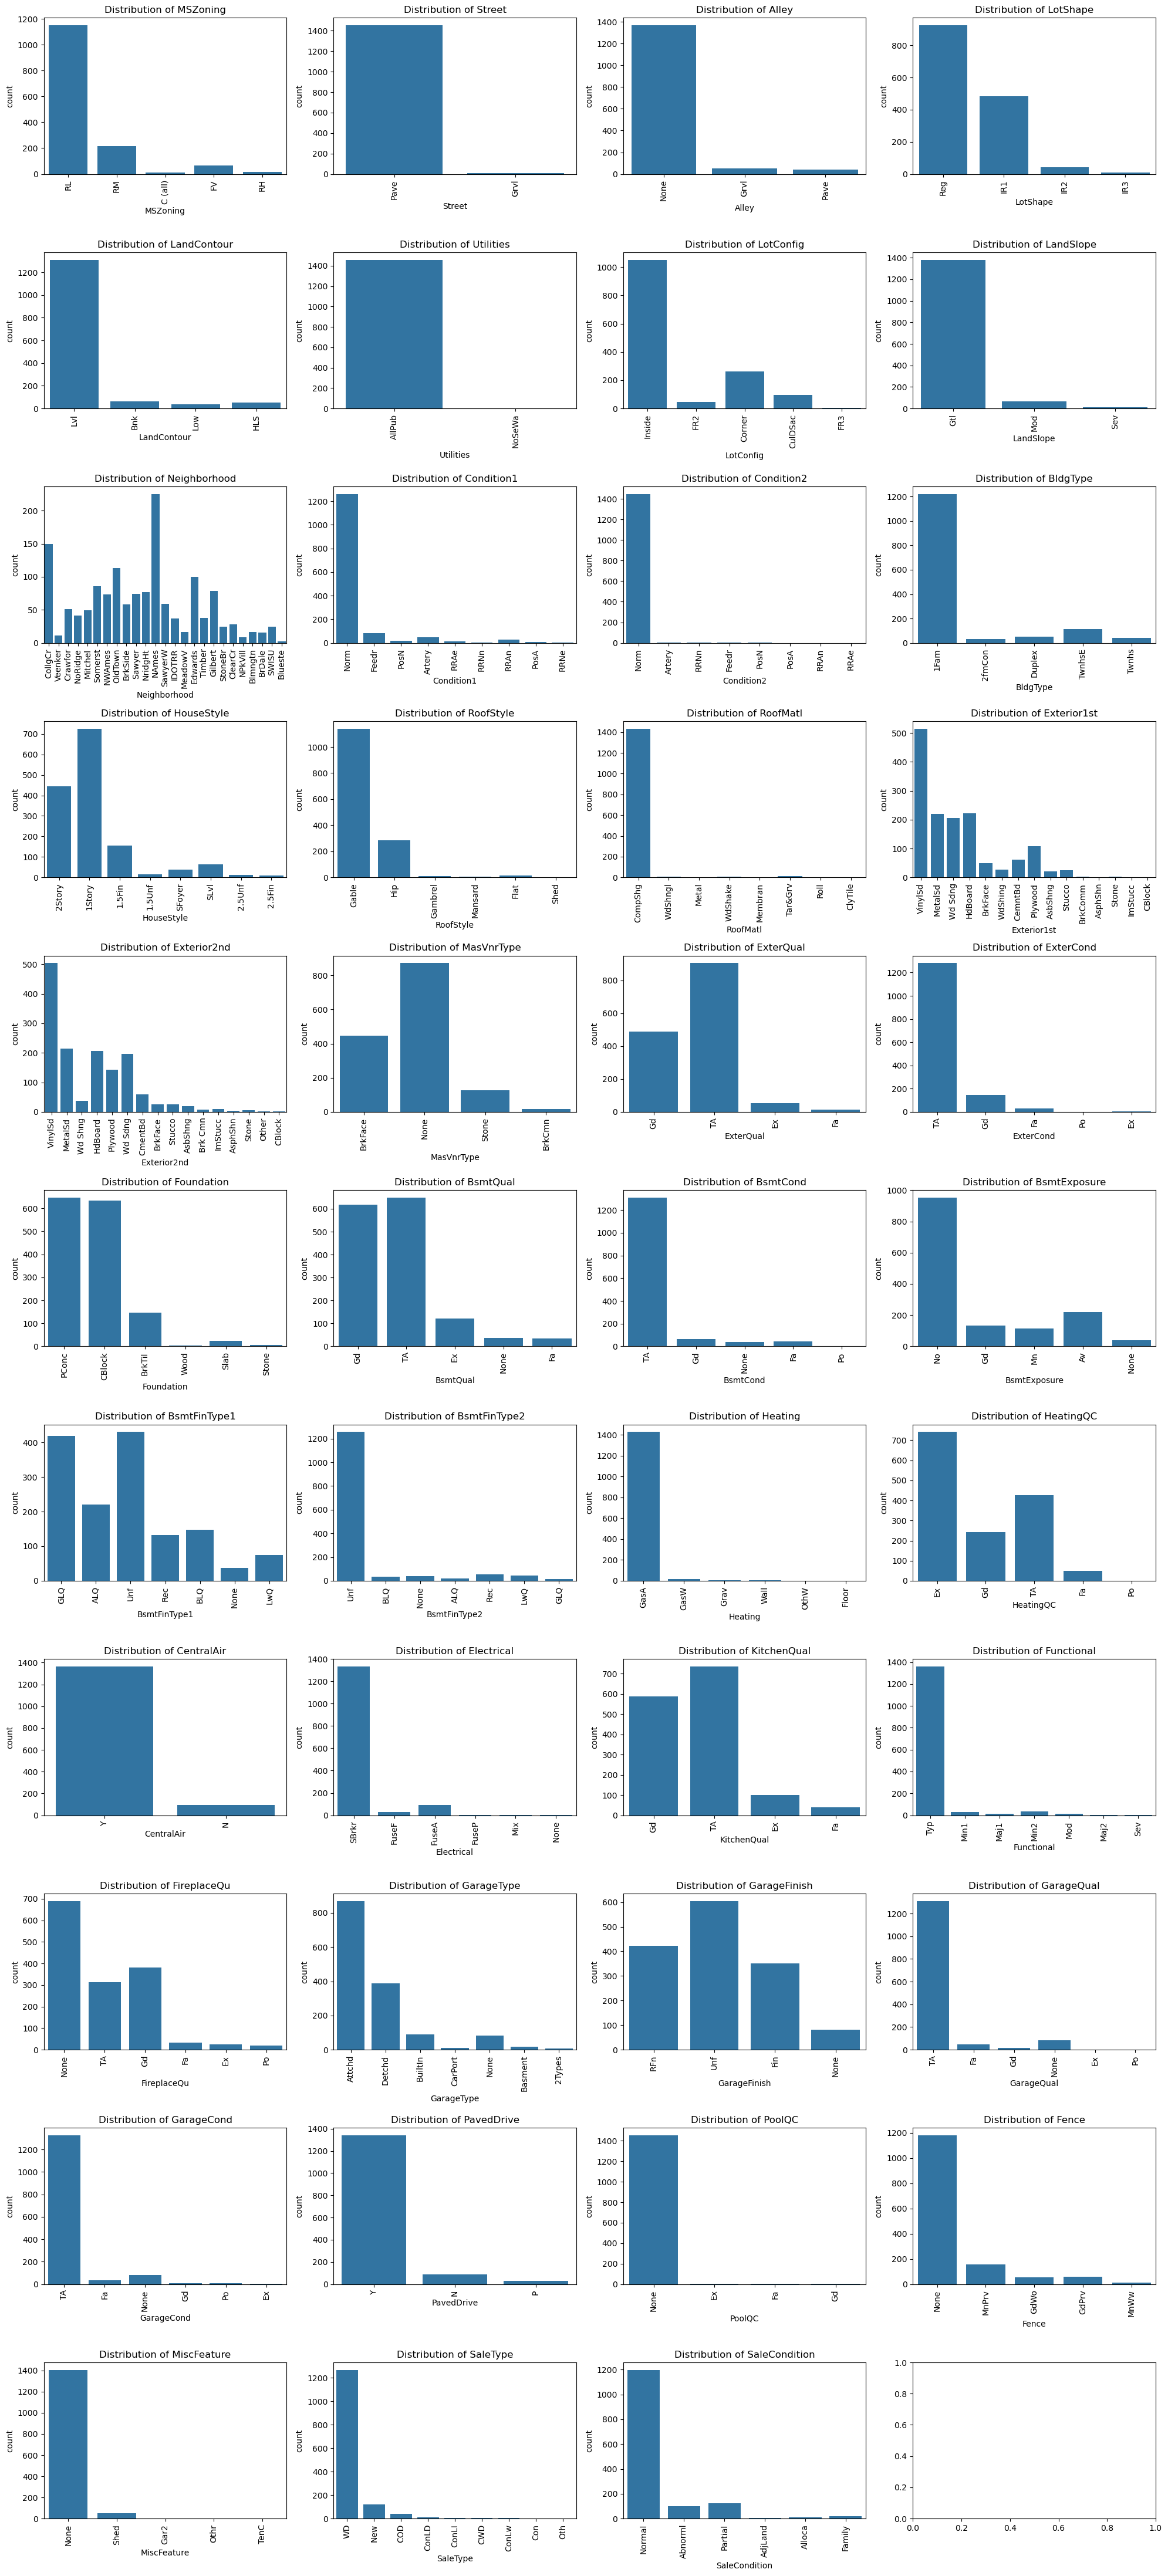

In [9]:
n_cols = 4
n_rows = (len(cathegorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten() # Flatten 

for i, col in enumerate(cathegorical_cols):
    sns.countplot(x=col, data=housing_data, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=90)
    
plt.tight_layout()

Some of the cathegorical variables have a specific order, to capture their correlation we need to encode them in the correct order.

In [10]:
from sklearn.preprocessing import OrdinalEncoder

ordered_cat_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond',
                    'PoolQC']

# Ordinal encoding of the quality features
quality_order = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
functional_order = ['None', 'Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']
fence_order = ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']

# Transform the quality features
quality_encoder = OrdinalEncoder(categories=[quality_order] * len(ordered_cat_cols))
cat_housing_data = housing_data.copy()
cat_housing_data[ordered_cat_cols] = quality_encoder.fit_transform(cat_housing_data[ordered_cat_cols])

# Transform the functional features
functional_encoder = OrdinalEncoder(categories=[functional_order])
cat_housing_data['Functional'] = functional_encoder.fit_transform(cat_housing_data[['Functional']])

# Transform the fence features
fence_encoder = OrdinalEncoder(categories=[fence_order])
cat_housing_data['Fence'] = fence_encoder.fit_transform(cat_housing_data[['Fence']])

# Encode the rest of the categorical features with label encoding
from sklearn.preprocessing import LabelEncoder

for col in cathegorical_cols:
    if col not in ordered_cat_cols + ['Functional', 'Fence']:
        le = LabelEncoder()
        cat_housing_data[col] = le.fit_transform(cat_housing_data[col])

<Axes: >

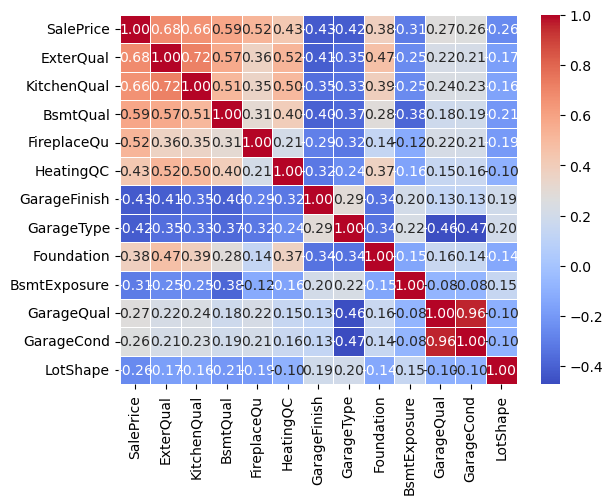

In [11]:
# Correlation matrix with the encoded features with the target variable
corr_target = cat_housing_data[list(cathegorical_cols) + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False, key=abs)

# Take the 30% top of the list
top_20_percent = int(len(corr_target) * 0.3)
top_vars = corr_target.head(top_20_percent)

corr = cat_housing_data[top_vars.index].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

### Mutual Information Analysis for feature selection

c:\Users\Spin\miniforge3\envs\ml_lab\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Text(0.5, 1.0, 'Mutual Information Scores')

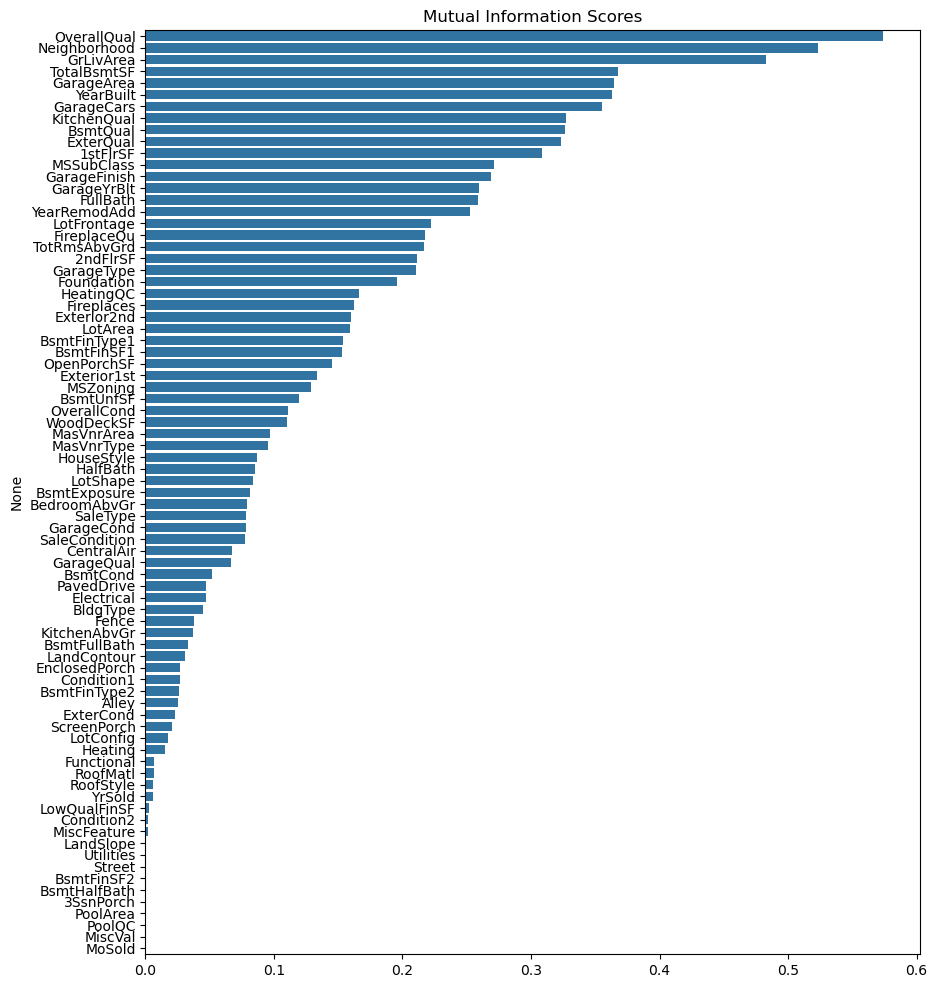

In [12]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

y_target = cat_housing_data['SalePrice']
X_input = cat_housing_data.drop(columns=['SalePrice', 'Id'])
discrete_features = [col in cathegorical_cols for col in X_input.columns]

mi_scores = make_mi_scores(X_input, y_target, discrete_features)

plt.figure(figsize=(10, 12))
sns.barplot(x=mi_scores.values, y=mi_scores.index)
plt.title("Mutual Information Scores")

Let's try fitting a GB Tree model with RFE to see how many features to actually select.

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold

# Scale the numerical data
num_cols = numerical_cols.drop(['SalePrice','Id'])
#

scaler = StandardScaler().fit(X_input[num_cols])
X_input[num_cols] = scaler.transform(X_input[num_cols])
y_target = StandardScaler().fit_transform(y_target.values.reshape(-1, 1)).flatten()

min_features = 5
model = GradientBoostingRegressor(n_estimators=100, random_state=1) 
cv = KFold(5)

rfecv = RFECV(estimator=model, step=1, cv=cv, scoring='neg_mean_squared_error', min_features_to_select=min_features, n_jobs=-1)
rfecv.fit(X_input, y_target)
print(f"Optimal number of features: {rfecv.n_features_}")
print(rfecv.support_)

Optimal number of features: 47
[False  True  True  True False False False  True False False False  True
  True False  True  True  True  True  True  True False False  True False
 False False  True False False  True False  True  True  True False  True
  True  True False  True  True False  True  True False  True  True False
  True  True  True False  True  True  True  True  True  True  True False
  True  True  True False False  True  True False False  True  True False
 False False False  True  True False  True]


<ErrorbarContainer object of 3 artists>

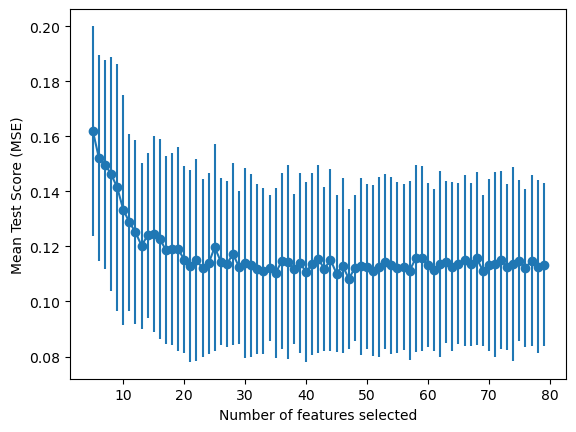

In [14]:
results = pd.DataFrame({key: value for key,value in rfecv.cv_results_.items() if key in ['n_features', 'mean_test_score', 'std_test_score']})

plt.figure()
plt.xlabel('Number of features selected')
plt.ylabel('Mean Test Score (MSE)')

plt.errorbar(results['n_features'], -results['mean_test_score'], yerr=results['std_test_score'], fmt='-o')

In [15]:
# Print the selected features after RFECV
selected_features = X_input.columns[rfecv.support_]
print("Selected features after RFECV:")
print(selected_features)

Selected features after RFECV:
Index(['MSZoning', 'LotFrontage', 'LotArea', 'LandContour', 'Neighborhood',
       'Condition1', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'ExterQual', 'BsmtQual',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'HeatingQC', 'CentralAir', '1stFlrSF', '2ndFlrSF',
       'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageCars', 'GarageArea',
       'GarageQual', 'WoodDeckSF', 'OpenPorchSF', 'ScreenPorch', 'PoolArea',
       'MoSold', 'YrSold', 'SaleCondition'],
      dtype='str')


In [ ]:
# Check the correlation for the selected features
